--- Normalized Data Head ---
            CO2_norm  CH4_norm  N2O_norm  Other_Gases_norm
Year                                                      
1992-01-01  0.000000  0.000000  0.000000            0.0000
1993-01-01  0.018676  0.000000  0.019231            0.2500
1994-01-01  0.059423  0.068966  0.057692            0.4375
1995-01-01  0.106961  0.172414  0.076923            0.5625
1996-01-01  0.154499  0.206897  0.134615            0.6875

Finding optimal lag order (maxlags=2)...
Optimal lag order (AIC): 2

--- Model Summary ---
  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Mon, 24, Nov, 2025
Time:                     20:00:58
--------------------------------------------------------------------
No. of Equations:         4.00000    BIC:                   -29.0721
Nobs:                     19.0000    HQIC:                  -30.5587
Log likelihood:           221.346    FPE:                5.49376e-14
AIC:           

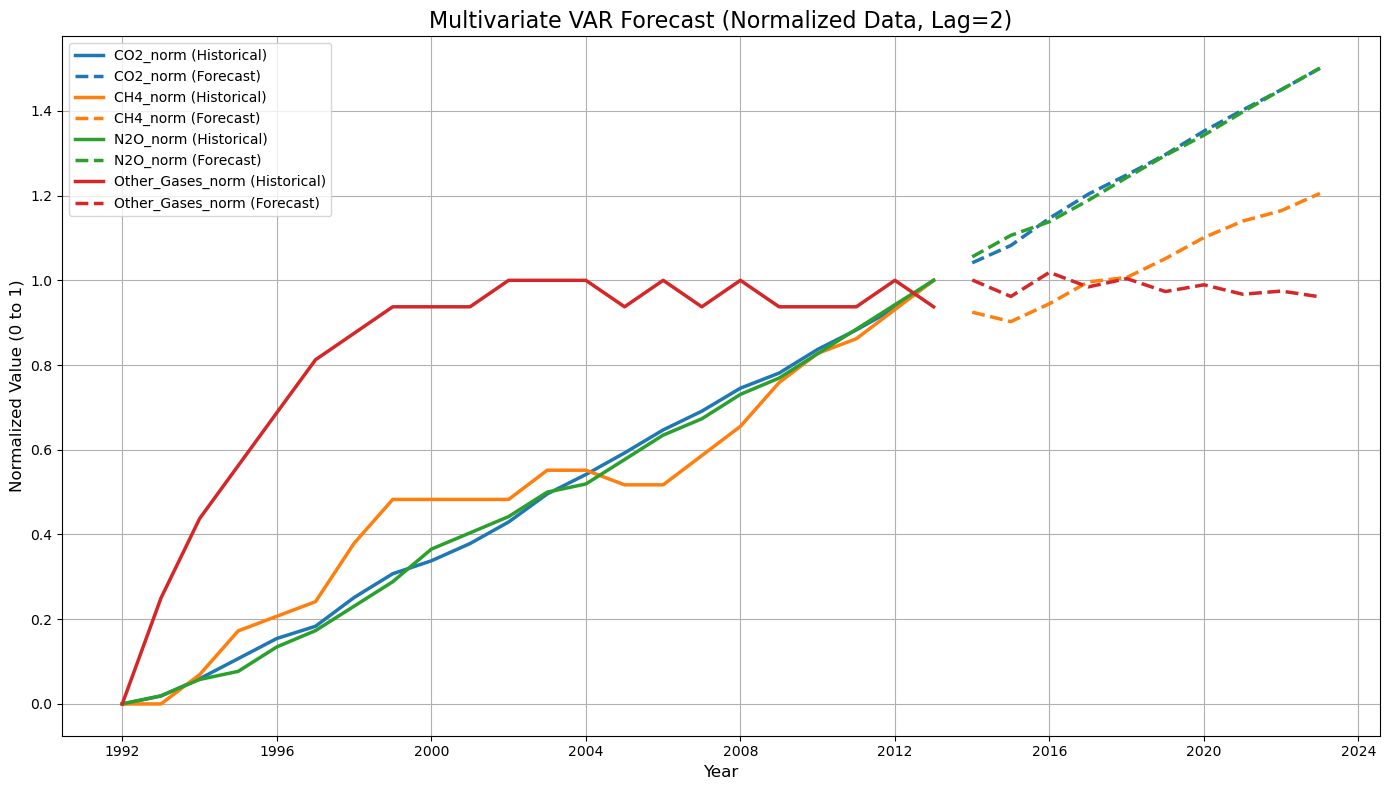

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.api import VAR
import warnings

# --- 0. Setup ---
# Suppress warnings (statsmodels can generate many)
warnings.filterwarnings("ignore")

# Define the normalized columns we want to model
cols_to_model = ['CO2_norm', 'CH4_norm', 'N2O_norm', 'Other_Gases_norm']
plot_file = 'normalized_gas_forecast_matched_colors.png'
plot_linewidth = 2.5

# --- 1. Load and Prepare the Data ---
try:
    df = pd.read_csv("normalized.csv")
except FileNotFoundError:
    print("Error: 'normalized.csv' not found.")
    exit()

# Select the columns we want to model
try:
    df_model = df[['Year'] + cols_to_model].copy()
except KeyError:
    print(f"Error: One or more columns ({cols_to_model}) not found in normalized.csv.")
    exit()

# Convert 'Year' to datetime and set as index
df_model['Year'] = pd.to_datetime(df_model['Year'], format='%Y')
df_model = df_model.set_index('Year').asfreq('YS')

print("--- Normalized Data Head ---")
print(df_model.head())

# --- 2. Make Data Stationary ---
df_differenced = df_model.diff().dropna()

# --- 3. Build and Fit the VAR Model ---
model_for_lag_selection = VAR(df_differenced)

print("\nFinding optimal lag order (maxlags=2)...")
try:
    order_selection = model_for_lag_selection.select_order(maxlags=2)
    best_lag = order_selection.aic
    print(f"Optimal lag order (AIC): {best_lag}")
except ValueError as e:
    print("Error during lag selection, defaulting to lag=1.")
    best_lag = 1
    
# Create and fit the final model using the best lag
model = VAR(df_differenced)
results = model.fit(best_lag)

print("\n--- Model Summary ---")
print(results.summary())


# --- 4. Make a Forecast ---
forecast_steps = 10
lag_order = results.k_ar 
last_known_inputs = df_differenced.values[-lag_order:]
forecast_diff = results.forecast(y=last_known_inputs, steps=forecast_steps)

# --- 5. "Un-difference" the Forecast ---
last_year = df_model.index[-1]
forecast_index = pd.date_range(
    start=last_year + pd.DateOffset(years=1),
    periods=forecast_steps,
    freq='YS'
)
forecast_df_diff = pd.DataFrame(
    forecast_diff,
    index=forecast_index,
    columns=cols_to_model
)
last_known_original = df_model.iloc[-1]
forecast_original = forecast_df_diff.cumsum() + last_known_original

print("\n--- Forecasted Values (Normalized Scale) ---")
print(forecast_original)

# --- 6. Plot Historical Data and Forecast (with Matched Colors) ---
print(f"\nGenerating forecast plot with matched colors and saving to {plot_file}...")
plt.figure(figsize=(14, 8))

# **USER REQUEST: Modified loop to match colors**
# Iterate through each column, plot both historical and forecast
# to ensure their colors match.
for col in cols_to_model:
    # Plot the historical line and get its color
    historical_line = plt.plot(
        df_model.index, 
        df_model[col], 
        label=f'{col} (Historical)',
        linewidth=plot_linewidth
    )
    # Get the color assigned by matplotlib
    line_color = historical_line[0].get_color()

    # Plot the forecast line using the *same color*
    plt.plot(
        forecast_original.index,
        forecast_original[col],
        label=f'{col} (Forecast)',
        linestyle='--',
        linewidth=plot_linewidth,
        color=line_color  # <-- This matches the color
    )

plt.title(f'Multivariate VAR Forecast (Normalized Data, Lag={best_lag})', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Normalized Value (0 to 1)', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True)
plt.tight_layout()

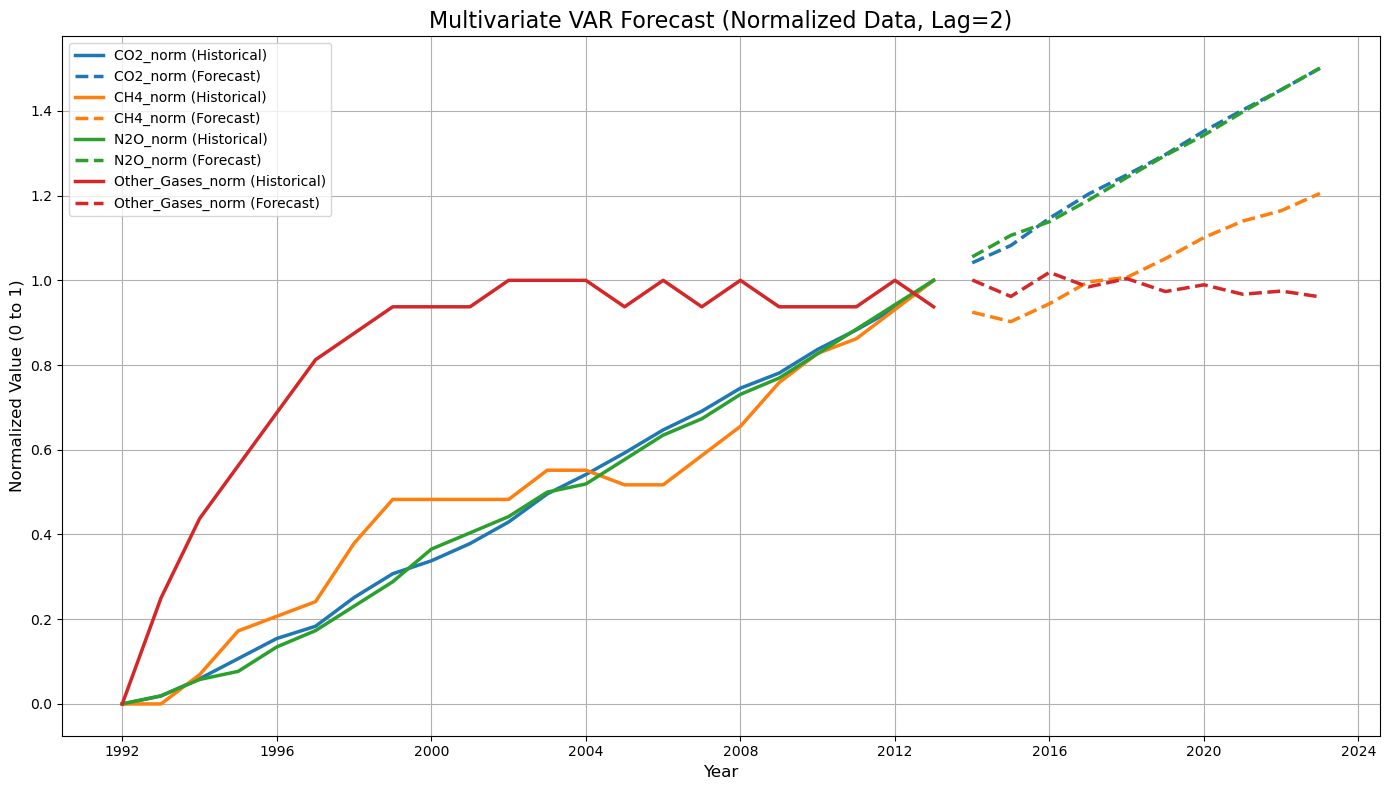

In [2]:
plt.figure(figsize=(14, 8))

# **USER REQUEST: Modified loop to match colors**
# Iterate through each column, plot both historical and forecast
# to ensure their colors match.
for col in cols_to_model:
    # Plot the historical line and get its color
    historical_line = plt.plot(
        df_model.index, 
        df_model[col], 
        label=f'{col} (Historical)',
        linewidth=plot_linewidth
    )
    # Get the color assigned by matplotlib
    line_color = historical_line[0].get_color()

    # Plot the forecast line using the *same color*
    plt.plot(
        forecast_original.index,
        forecast_original[col],
        label=f'{col} (Forecast)',
        linestyle='--',
        linewidth=plot_linewidth,
        color=line_color  # <-- This matches the color
    )

plt.title(f'Multivariate VAR Forecast (Normalized Data, Lag={best_lag})', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Normalized Value (0 to 1)', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True)
plt.tight_layout()

--- Correlation Matrix ---
                                  CO2_norm  CH4_norm  N2O_norm  \
CO2_norm                          1.000000  0.969459  0.998863   
CH4_norm                          0.969459  1.000000  0.971931   
N2O_norm                          0.998863  0.971931  1.000000   
Other_Gases_norm                  0.715683  0.779562  0.714721   
AverageTemperature: Celsius_norm  0.777700  0.810555  0.775995   
gmsl_mm_norm                      0.990886  0.962494  0.989565   
sea_level_smooth_norm             0.994084  0.946926  0.993354   
AGGI_norm                         0.999788  0.973295  0.999031   

                                  Other_Gases_norm  \
CO2_norm                                  0.715683   
CH4_norm                                  0.779562   
N2O_norm                                  0.714721   
Other_Gases_norm                          1.000000   
AverageTemperature: Celsius_norm          0.769137   
gmsl_mm_norm                              0.752079   


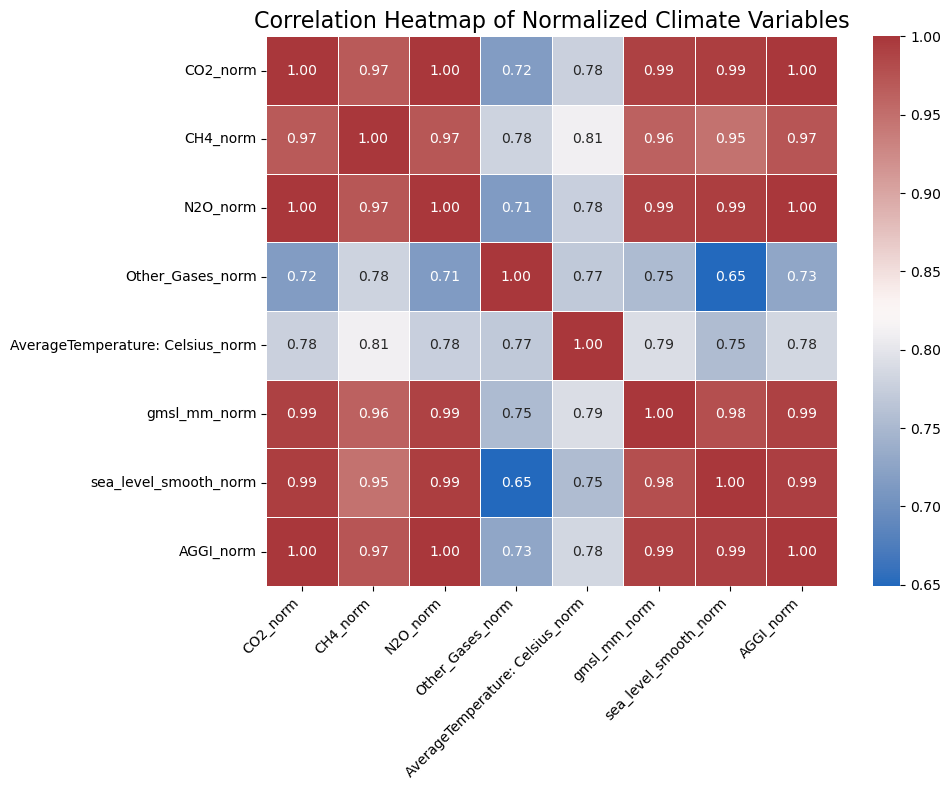

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- 1. Load the Data ---
try:
    df = pd.read_csv("normalized.csv")
except FileNotFoundError:
    print("Error: 'normalized.csv' not found.")
    exit()

# --- 2. Select Relevant Columns ---
# We'll select the key normalized variables to see their relationships
# This includes the gases we modeled and the environmental impact variables
columns_for_heatmap = [
    # Gases
    'CO2_norm', 
    'CH4_norm', 
    'N2O_norm', 
    'Other_Gases_norm',
    
    # Environmental Metrics
    'AverageTemperature: Celsius_norm', # Temperature
    'gmsl_mm_norm',                     # Global Mean Sea Level
    'sea_level_smooth_norm',            # Global Mean Sea Level (Smoothed)
    'AGGI_norm'                         # Annual Greenhouse Gas Index
]

# Check if all columns exist
missing_cols = [col for col in columns_for_heatmap if col not in df.columns]
if missing_cols:
    print(f"Error: The following columns are missing from normalized.csv: {missing_cols}")
    # Fallback to only columns that *do* exist, if any
    columns_for_heatmap = [col for col in columns_for_heatmap if col in df.columns]
    if len(columns_for_heatmap) < 2:
        print("Not enough data to create a heatmap. Exiting.")
        exit()
    print(f"Creating heatmap with available columns: {columns_for_heatmap}")

df_heatmap = df[columns_for_heatmap]

# --- 3. Calculate Correlation Matrix ---
corr_matrix = df_heatmap.corr()

# Print the matrix for the user to see the exact values
print("--- Correlation Matrix ---")
print(corr_matrix)

# --- 4. Generate the Heatmap ---
print("\nGenerating correlation heatmap...")
plt.figure(figsize=(10, 8))

heatmap = sns.heatmap(
    corr_matrix,
    annot=True,          # Show the correlation values on the plot
    cmap='vlag',         # Use a diverging colormap (red=positive, blue=negative)
    fmt='.2f',           # Format the values to 2 decimal places
    linewidths=.5        # Add thin lines between cells
)

plt.title('Correlation Heatmap of Normalized Climate Variables', fontsize=16)
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for readability
plt.yticks(rotation=0)
plt.tight_layout() # Adjust plot to prevent labels from overlapping

# Save the plot
plot_file = 'correlation_heatmap.png'
plt.savefig(plot_file)

print(f"Heatmap saved to {plot_file}")

--- Correlation Matrix of Year-to-Year Changes (Differenced Data) ---
                                  CO2_norm  CH4_norm  N2O_norm  \
CO2_norm                          1.000000  0.415529  0.439891   
CH4_norm                          0.415529  1.000000  0.055344   
N2O_norm                          0.439891  0.055344  1.000000   
Other_Gases_norm                 -0.393129  0.008023 -0.371532   
AverageTemperature: Celsius_norm  0.109398  0.201470 -0.108637   
gmsl_mm_norm                     -0.265254 -0.208052 -0.095106   
sea_level_smooth_norm             0.349567 -0.078771  0.284927   
AGGI_norm                         0.969206  0.556675  0.470856   
land_smooth_norm                  0.244765  0.098829  0.045417   

                                  Other_Gases_norm  \
CO2_norm                                 -0.393129   
CH4_norm                                  0.008023   
N2O_norm                                 -0.371532   
Other_Gases_norm                          1.000000   

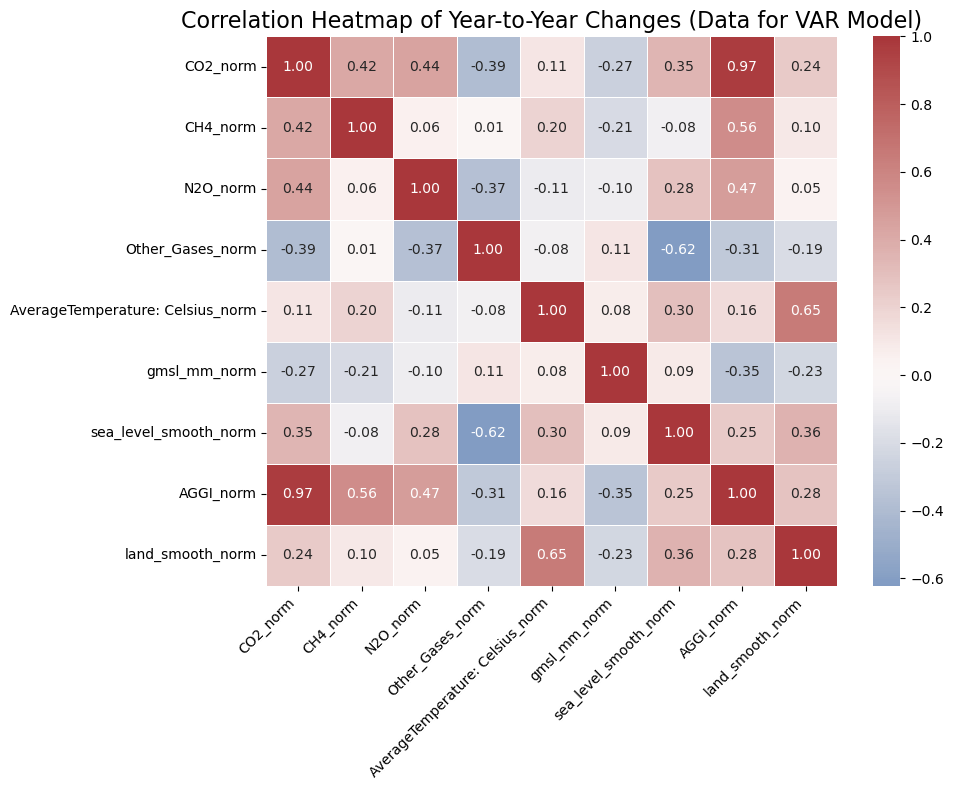

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- 1. Load the Data ---
try:
    df = pd.read_csv("normalized.csv")
except FileNotFoundError:
    print("Error: 'normalized.csv' not found.")
    exit()

# --- 2. Select Relevant Columns ---
# We'll select the key normalized variables to see their relationships
columns_for_heatmap = [
    'CO2_norm', 
    'CH4_norm', 
    'N2O_norm', 
    'Other_Gases_norm',
    'AverageTemperature: Celsius_norm',
    'gmsl_mm_norm',
    'sea_level_smooth_norm',
    'AGGI_norm',
    'land_smooth_norm'
]

# Check for missing columns (robustness)
available_cols = [col for col in columns_for_heatmap if col in df.columns]
df_selected = df[available_cols]

# --- 3. Difference the Data (Insight 1) ---
# This is the key step. We calculate the year-to-year change.
# This removes the long-term trend and shows the "fluctuations".
df_differenced = df_selected.diff().dropna()
# .dropna() removes the first row, which is NaN after differencing

# --- 4. Calculate Correlation Matrix of Differenced Data ---
corr_matrix_diff = df_differenced.corr()

# Print the matrix for the user to see the exact values
print("--- Correlation Matrix of Year-to-Year Changes (Differenced Data) ---")
print(corr_matrix_diff)

# --- 5. Generate the "VAR Heatmap" ---
print("\nGenerating heatmap of year-to-year changes...")
plt.figure(figsize=(10, 8))

heatmap = sns.heatmap(
    corr_matrix_diff,
    annot=True,          # Show the correlation values
    cmap='vlag',         # Use a diverging colormap (red=positive, blue=negative)
    center=0,            # Center the colormap at 0 (no correlation)
    fmt='.2f',           # Format the values to 2 decimal places
    linewidths=.5        
)

plt.title('Correlation Heatmap of Year-to-Year Changes (Data for VAR Model)', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

# Save the plot
plot_file = 'correlation_heatmap_differenced.png'
plt.savefig(plot_file)

print(f"Heatmap saved to {plot_file}")

--- Normalized Data Head ---
            CO2_norm  CH4_norm  N2O_norm  Other_Gases_norm  land_smooth_norm  \
Year                                                                           
1992-01-01  0.000000  0.000000  0.000000            0.0000               0.0   
1993-01-01  0.018676  0.000000  0.019231            0.2500               0.0   
1994-01-01  0.059423  0.068966  0.057692            0.4375               0.0   
1995-01-01  0.106961  0.172414  0.076923            0.5625               0.0   
1996-01-01  0.154499  0.206897  0.134615            0.6875               0.0   

            sea_level_smooth_norm  
Year                               
1992-01-01                    0.0  
1993-01-01                    0.0  
1994-01-01                    0.0  
1995-01-01                    0.0  
1996-01-01                    0.0  

Finding optimal lag order (maxlags=2)...
Optimal lag order (AIC): 2

--- Model Summary ---
Could not print model summary: VARResults.summary() got an unexpec

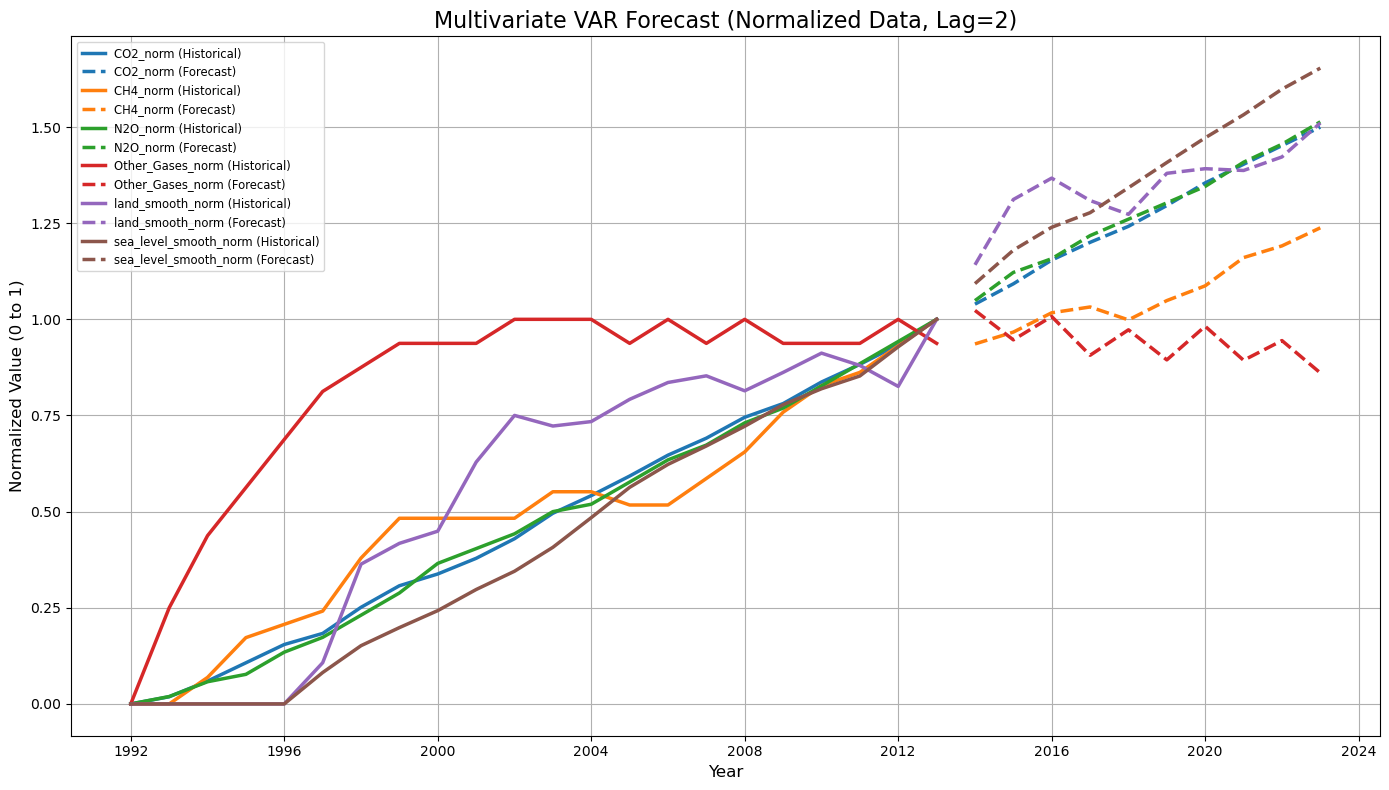


Script finished.


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.api import VAR
import warnings

# --- 0. Setup ---
# Suppress warnings (statsmodels can generate many)
warnings.filterwarnings("ignore")

# Define the normalized columns we want to model
# **USER REQUEST: Added land_smooth_norm and sea_level_smooth_norm**
cols_to_model = [
    'CO2_norm', 
    'CH4_norm', 
    'N2O_norm', 
    'Other_Gases_norm',
    'land_smooth_norm',
    'sea_level_smooth_norm'
]
# Updated filenames
data_file = "allTemperatureAndGGDataNormalized.csv" 
plot_file = 'normalized_gas_and_temp_forecast.png'
plot_linewidth = 2.5

# --- 1. Load and Prepare the Data ---
try:
    # **MODIFIED: Use the uploaded filename**
    df = pd.read_csv(data_file) 
except FileNotFoundError:
    print(f"Error: '{data_file}' not found.")
    print("Please make sure the file is in the same directory as the script.")
    exit()

# Select the columns we want to model
try:
    df_model = df[['Year'] + cols_to_model].copy()
except KeyError as e:
    print(f"Error: Column not found in {data_file}.")
    print(f"Missing column: {e}")
    print("Please check the column names in your CSV.")
    exit()

# Convert 'Year' to datetime and set as index
df_model['Year'] = pd.to_datetime(df_model['Year'], format='%Y')
df_model = df_model.set_index('Year').asfreq('YS')

# Handle potential missing values at the start/end if asfreq introduced NaNs
df_model = df_model.ffill().bfill() 

print("--- Normalized Data Head ---")
print(df_model.head())

# --- 2. Make Data Stationary ---
# Check for and handle any NaNs *before* differencing
if df_model.isnull().values.any():
    print("Warning: Missing values found. Applying forward fill before differencing.")
    df_model = df_model.ffill()

df_differenced = df_model.diff().dropna()

# Check if differencing created all-zero columns (if data was constant)
if (df_differenced == 0).all().any():
    print("Warning: At least one column is constant. VAR model may be unstable.")
    
# --- 3. Build and Fit the VAR Model ---
model_for_lag_selection = VAR(df_differenced)

print("\nFinding optimal lag order (maxlags=2)...")
try:
    # Note: With more variables, maxlags=2 might be too small,
    # but we'll stick to it as per the original script.
    order_selection = model_for_lag_selection.select_order(maxlags=2)
    best_lag = order_selection.aic
    # Handle case where select_order returns a dictionary
    if isinstance(best_lag, dict):
        best_lag = best_lag['aic']
        
    # Handle cases where no lag is selected (returns -1)
    if best_lag == -1:
        print("AIC did not find a suitable lag, defaulting to 1.")
        best_lag = 1
    else:
        print(f"Optimal lag order (AIC): {best_lag}")
        
except Exception as e:
    print(f"Error during lag selection ({e}), defaulting to lag=1.")
    best_lag = 1
    
# Create and fit the final model using the best lag
model = VAR(df_differenced)
results = model.fit(best_lag)

print("\n--- Model Summary ---")
# This summary can be very large with 6 variables, so we only print
# the summary for the first variable as a check.
try:
    print(results.summary(endog=cols_to_model[0]))
except Exception as e:
    print(f"Could not print model summary: {e}")


# --- 4. Make a Forecast ---
forecast_steps = 10
lag_order = results.k_ar 

# Ensure we have enough data for the lag order
if len(df_differenced) < lag_order:
    print(f"Error: Not enough data ({len(df_differenced)} rows) for lag order {lag_order}.")
    exit()
    
last_known_inputs = df_differenced.values[-lag_order:]
forecast_diff = results.forecast(y=last_known_inputs, steps=forecast_steps)

# --- 5. "Un-difference" the Forecast ---
last_year = df_model.index[-1]
forecast_index = pd.date_range(
    start=last_year + pd.DateOffset(years=1),
    periods=forecast_steps,
    freq='YS'
)
forecast_df_diff = pd.DataFrame(
    forecast_diff,
    index=forecast_index,
    columns=cols_to_model # Columns should match the order
)
last_known_original = df_model.iloc[-1]
forecast_original = forecast_df_diff.cumsum() + last_known_original

print("\n--- Forecasted Values (Normalized Scale) ---")
print(forecast_original)

# --- 6. Plot Historical Data and Forecast (with Matched Colors) ---
print(f"\nGenerating forecast plot with matched colors and saving to {plot_file}...")
plt.figure(figsize=(14, 8))

# Iterate through each column, plot both historical and forecast
# to ensure their colors match.
for col in cols_to_model:
    # Plot the historical line and get its color
    historical_line = plt.plot(
        df_model.index, 
        df_model[col], 
        label=f'{col} (Historical)',
        linewidth=plot_linewidth
    )
    # Get the color assigned by matplotlib
    line_color = historical_line[0].get_color()

    # Plot the forecast line using the *same color*
    plt.plot(
        forecast_original.index,
        forecast_original[col],
        label=f'{col} (Forecast)',
        linestyle='--',
        linewidth=plot_linewidth,
        color=line_color  # <-- This matches the color
    )

plt.title(f'Multivariate VAR Forecast (Normalized Data, Lag={best_lag})', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Normalized Value (0 to 1)', fontsize=12)
plt.legend(loc='upper left', fontsize='small')
plt.grid(True)
plt.tight_layout()
plt.savefig(plot_file)
print(f"Plot saved to {plot_file}")
plt.show() # <-- Add this line to *try* and show the plot
plt.close()

print("\nScript finished.")

In [6]:
# *** --- START OF ADDED CODE --- ***
# Print the model coefficients
print("\n--- Model Coefficients (Lag={best_lag}) ---")
coefficients_df = results.params
print(coefficients_df)
# *** --- END OF ADDED CODE --- ***


--- Model Coefficients (Lag={best_lag}) ---
                          CO2_norm  CH4_norm  N2O_norm  Other_Gases_norm  \
const                     0.087609  0.243338  0.064460          0.064313   
L1.CO2_norm              -0.400290 -4.770109 -0.497617          1.334509   
L1.CH4_norm               0.063684  1.323708  0.129606         -0.197220   
L1.N2O_norm              -0.201129  0.896130 -0.380001          0.387622   
L1.Other_Gases_norm      -0.032552  0.430018  0.011489         -0.476892   
L1.land_smooth_norm       0.002002  0.274516  0.067376          0.451364   
L1.sea_level_smooth_norm  0.310456 -0.038077  0.110747         -1.209731   
L2.CO2_norm              -0.233212  1.702071  0.449962          0.694298   
L2.CH4_norm              -0.078731 -0.908131  0.093902         -0.167356   
L2.N2O_norm              -0.101727 -1.951259 -0.275669         -0.552736   
L2.Other_Gases_norm      -0.021765 -0.597657 -0.077137          0.361824   
L2.land_smooth_norm       0.033141 -0.02132

--- Coefficients to Plot (without 'const' row) ---
                          CO2_norm  CH4_norm  N2O_norm  Other_Gases_norm  \
L1.CO2_norm              -0.400290 -4.770109 -0.497617          1.334509   
L1.CH4_norm               0.063684  1.323708  0.129606         -0.197220   
L1.N2O_norm              -0.201129  0.896130 -0.380001          0.387622   
L1.Other_Gases_norm      -0.032552  0.430018  0.011489         -0.476892   
L1.land_smooth_norm       0.002002  0.274516  0.067376          0.451364   
L1.sea_level_smooth_norm  0.310456 -0.038077  0.110747         -1.209731   
L2.CO2_norm              -0.233212  1.702071  0.449962          0.694298   
L2.CH4_norm              -0.078731 -0.908131  0.093902         -0.167356   
L2.N2O_norm              -0.101727 -1.951259 -0.275669         -0.552736   
L2.Other_Gases_norm      -0.021765 -0.597657 -0.077137          0.361824   
L2.land_smooth_norm       0.033141 -0.021326  0.030289         -0.043731   
L2.sea_level_smooth_norm -0.166366 -0

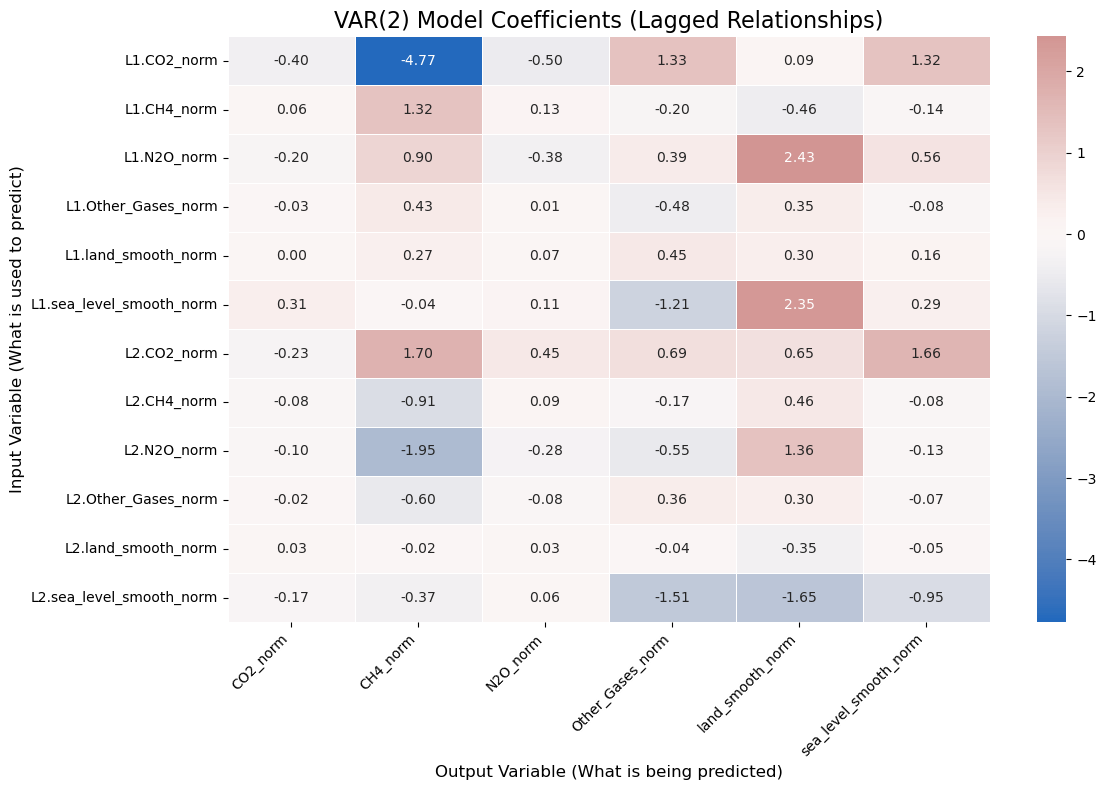

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.api import VAR
import warnings

# --- 0. Setup ---
warnings.filterwarnings("ignore")

cols_to_model = [
    'CO2_norm', 
    'CH4_norm', 
    'N2O_norm', 
    'Other_Gases_norm',
    'land_smooth_norm',
    'sea_level_smooth_norm'
]
data_file = "normalized.csv" 
plot_file = 'var_coefficients_heatmap.png'

# --- 1. Load and Prepare the Data ---
try:
    df = pd.read_csv(data_file) 
except FileNotFoundError:
    print(f"Error: '{data_file}' not found.")
    exit()

try:
    if 'Unnamed: 0' in df.columns:
        df = df.drop(columns=['Unnamed: 0'])
    df_model = df[['Year'] + cols_to_model].copy()
except KeyError as e:
    print(f"Error: Column not found in {data_file}.")
    exit()

df_model['Year'] = pd.to_datetime(df_model['Year'], format='%Y')
df_model = df_model.set_index('Year').asfreq('YS')
df_model = df_model.ffill().bfill() 

# --- 2. Make Data Stationary ---
df_differenced = df_model.diff().dropna()

# --- 3. Fit the VAR Model ---
# We previously found the best lag to be 2
best_lag = 2
model = VAR(df_differenced)
results = model.fit(best_lag)

# --- 4. Get Coefficients for Plotting ---
coefficients_df = results.params
# Drop the 'const' row as it's not a lagged variable
# and will skew the heatmap's color scale.
coefficients_to_plot = coefficients_df.drop('const')

print("--- Coefficients to Plot (without 'const' row) ---")
print(coefficients_to_plot)

# --- 5. Generate the Coefficients Heatmap ---
print(f"\nGenerating coefficients heatmap and saving to {plot_file}...")
plt.figure(figsize=(12, 8))

sns.heatmap(
    coefficients_to_plot,
    annot=True,         # Show the coefficient values
    cmap='vlag',        # Use a diverging colormap (red=positive, blue=negative)
    center=0,           # Center the colormap at 0 (no effect)
    fmt='.2f',          # Format the values to 2 decimal places
    linewidths=.5       
)

plt.title(f'VAR(2) Model Coefficients (Lagged Relationships)', fontsize=16)
plt.xlabel('Output Variable (What is being predicted)', fontsize=12)
plt.ylabel('Input Variable (What is used to predict)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()